In [1]:
import numpy as np 
import matplotlib.pyplot as plt

import sys
sys.path.append('..')

from PyESRSTM import Electrode, QD, rates, QME, sum_rates
from PyESRSTM.postproces.dynamics import Bexch, Trel, Szacc
from PyESRSTM import units

In [2]:
def calc_drive(Vdcs, Vrf, A, nmax):
    Nint = 1e4
    dot = QD(-30, 100, np.array([0.5]), np.array([[0.20804273,  0.00000000,  0.57159271]]), np.array([[2.0, 2.0, 2.0]]))
    Right = Electrode(0, 0, 0., 5e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30, Nint]])
    GRplus, GRminus = rates(dot, Right, 20, 0)
    GR = GRplus+GRminus
    

    B = np.empty((len(Vdcs), nmax))
    Sz = np.empty((len(Vdcs), nmax))
    
    for i, Vdc in enumerate(Vdcs):
        Left = Electrode(Vdc, Vrf, .5, 1.25e-3, 1e-1, 4.5, Nint=Nint, Cutoff=1000, Adrive=A, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30,Nint]])
        GLplus, GLminus = rates(dot, Left, 20, nmax)
        GL = GLplus+GLminus
        G=sum_rates(GL, GR)
        rho = QME(G, 20., Delta=dot.Delta)

        for n in range(nmax):       
            B[i,n]  = Bexch(G, dot.theta,n=n)*units.Hartree/units.GHz
            Sz[i,n] = Szacc(G, rho, dot.theta,n=n)*units.Hartree/units.GHz
    return B, Sz

Vdcs = np.linspace(-40, -20, 100)
BA, SzA = calc_drive(Vdcs, 0, .3, 4)
BVrf, SzVrf = calc_drive(Vdcs, 5, 0, 4)

# convert to MHz
BA *= 1000
SzA *= 1000
BVrf *= 1000
SzVrf *= 1000



Hermiticity check passed!
Hermiticity check passed!


/tmp/ipykernel_1249240/3972259423.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[3,0].legend()


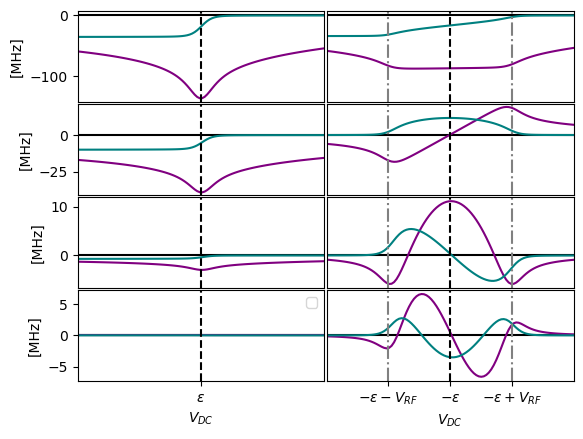

In [3]:
fig, ax = plt.subplots(4,2)
plt.subplots_adjust(wspace=.01,hspace=.02)

ax[0,0].plot(Vdcs,  -BA[:, 0], color='purple')
ax[0,0].plot(Vdcs, SzA[:, 0], color='teal')
ax[1,0].plot(Vdcs,  -BA[:, 1], color='purple')
ax[1,0].plot(Vdcs, SzA[:, 1], color='teal')
ax[2,0].plot(Vdcs,  -BA[:, 2], color='purple')
ax[2,0].plot(Vdcs, SzA[:, 2], color='teal')
ax[3,0].plot(Vdcs,  -BA[:, 3], color='purple')
ax[3,0].plot(Vdcs, SzA[:, 3], color='teal')

ax[0,1].plot(Vdcs,  -BVrf[:, 0], color='purple')
ax[0,1].plot(Vdcs, SzVrf[:, 0], color='teal')
ax[1,1].plot(Vdcs,  -BVrf[:, 1], color='purple')
ax[1,1].plot(Vdcs, SzVrf[:, 1], color='teal')
ax[2,1].plot(Vdcs,  -BVrf[:, 2], color='purple')
ax[2,1].plot(Vdcs, SzVrf[:, 2], color='teal')
ax[3,1].plot(Vdcs,  -BVrf[:, 3], color='purple', label='$B_{xc;n}$')
ax[3,1].plot(Vdcs, SzVrf[:, 3], color='teal', label=r'$\langle S_z \rangle_{acc;n}$')

for a in ax.flatten():
    a.set_xticks([])

for i in range(4):
    ylim1 = ax[i,0].get_ylim()
    ylim2 = ax[i,1].get_ylim()
    ylim = (min(ylim1[0], ylim2[0]),max(ylim1[1], ylim2[1]))

    ax[i,1].set_ylim(ylim)
    ax[i,0].set_ylim(ylim)
    ax[i,1].set_yticks([])

    ax[i,0].vlines([-30], *ylim, 'k', '--')
    ax[i,1].vlines([-30], *ylim, 'k', '--')
    ax[i,1].vlines([-35, -25], *ylim, 'gray', '-.')

    ax[i,1].hlines([0], -40, -20, 'k', '-', zorder=-1)
    ax[i,0].hlines([0], -40, -20, 'k', '-', zorder=-1)

    ax[i,0].set_ylabel(r'[MHz]')
    
    ax[i,0].set_xlim(-40,-20)
    ax[i,1].set_xlim(-40,-20)

ax[3,0].set_xticks([-30],[r'$\epsilon$'])
ax[3,1].set_xticks([-35,-30,-25],[r'$-\epsilon-V_{RF}$', r'$-\epsilon$', r'$-\epsilon+V_{RF}$'])

ax[3,0].set_xlabel(r'$V_{DC}$')
ax[3,1].set_xlabel(r'$V_{DC}$')

ax[3,0].legend()
plt.show()